# پروژه پیش‌بینی شاخص بورس ایران
## Notebook 03 — مدل GRU (شبکه عصبی بازگشتی)

| موضوع | جزئیات |
|-------|---------|
| متغیر هدف | `log_stock_price` — دنباله زمانی یک‌متغیره |
| اندازه پنجره | ۸ فصل = ۲ سال |
| معماری | GRU(32) × 2 لایه → Dropout → Linear(1) |
| Framework | **PyTorch** |
| نمودارها | ۱۲ نمودار از ۸ نوع مختلف |

> **پیش‌نیاز نصب:**
> ```bash
> pip install torch
> pip install arabic-reshaper python-bidi
> ```

## ۱. بارگذاری کتابخانه‌ها

In [23]:
import os, sys, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

import arabic_reshaper
from bidi.algorithm import get_display

# ── PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

sys.path.append("..")
from src.utils import load_data, get_train_test

def fp(text):
    return get_display(arabic_reshaper.reshape(str(text)))

# ── تنظیم seed برای تکرارپذیری
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.dpi"]  = 120
plt.rcParams["grid.alpha"]  = 0.3
plt.rcParams["font.family"] = "DejaVu Sans"
os.makedirs("../results/figures", exist_ok=True)

print(f"✓ PyTorch : {torch.__version__}")
print(f"✓ Device  : {DEVICE}")

✓ PyTorch : 2.12.0+cpu
✓ Device  : cpu


## ۲. بارگذاری داده و ساخت دنباله‌های زمانی

In [24]:
df = load_data()
train, test = get_train_test(df, test_quarters=16)

# ── پارامترهای اصلی
WINDOW = 8          # اندازه پنجره: 8 فصل = 2 سال
N_TRAIN = len(train)
N_TEST  = len(test)
print(f"✓ آموزش: {N_TRAIN} مشاهده | آزمون: {N_TEST} مشاهده | پنجره: {WINDOW}")

# ── نرمال‌سازی MinMax روی داده آموزش
y_raw   = pd.concat([train["log_stock_price"], test["log_stock_price"]]).values
scaler  = MinMaxScaler(feature_range=(0, 1))
y_train_sc = scaler.fit_transform(train["log_stock_price"].values.reshape(-1,1)).flatten()
y_test_sc  = scaler.transform(test["log_stock_price"].values.reshape(-1,1)).flatten()
y_all_sc   = np.concatenate([y_train_sc, y_test_sc])

# ── ساخت دنباله‌های آموزش
X_seq_tr, y_seq_tr = [], []
for i in range(N_TRAIN - WINDOW):
    X_seq_tr.append(y_train_sc[i:i+WINDOW])
    y_seq_tr.append(y_train_sc[i+WINDOW])
X_seq_tr = np.array(X_seq_tr)[..., np.newaxis].astype(np.float32)  # (67, 8, 1)
y_seq_tr = np.array(y_seq_tr, dtype=np.float32)

# ── ساخت دنباله‌های آزمون (پنجره کشویی با مقادیر واقعی)
X_seq_te, y_seq_te = [], []
for t in range(N_TEST):
    start = N_TRAIN - WINDOW + t
    X_seq_te.append(y_all_sc[start : start+WINDOW])
    y_seq_te.append(y_all_sc[N_TRAIN + t])
X_seq_te = np.array(X_seq_te)[..., np.newaxis].astype(np.float32)  # (16, 8, 1)
y_seq_te = np.array(y_seq_te, dtype=np.float32)

print(f"✓ دنباله‌های آموزش : {X_seq_tr.shape}")
print(f"✓ دنباله‌های آزمون : {X_seq_te.shape}")

✓ آموزش: 75 مشاهده | آزمون: 16 مشاهده | پنجره: 8
✓ دنباله‌های آموزش : (67, 8, 1)
✓ دنباله‌های آزمون : (16, 8, 1)


## ۳. تصویرسازی ساختار پنجره کشویی

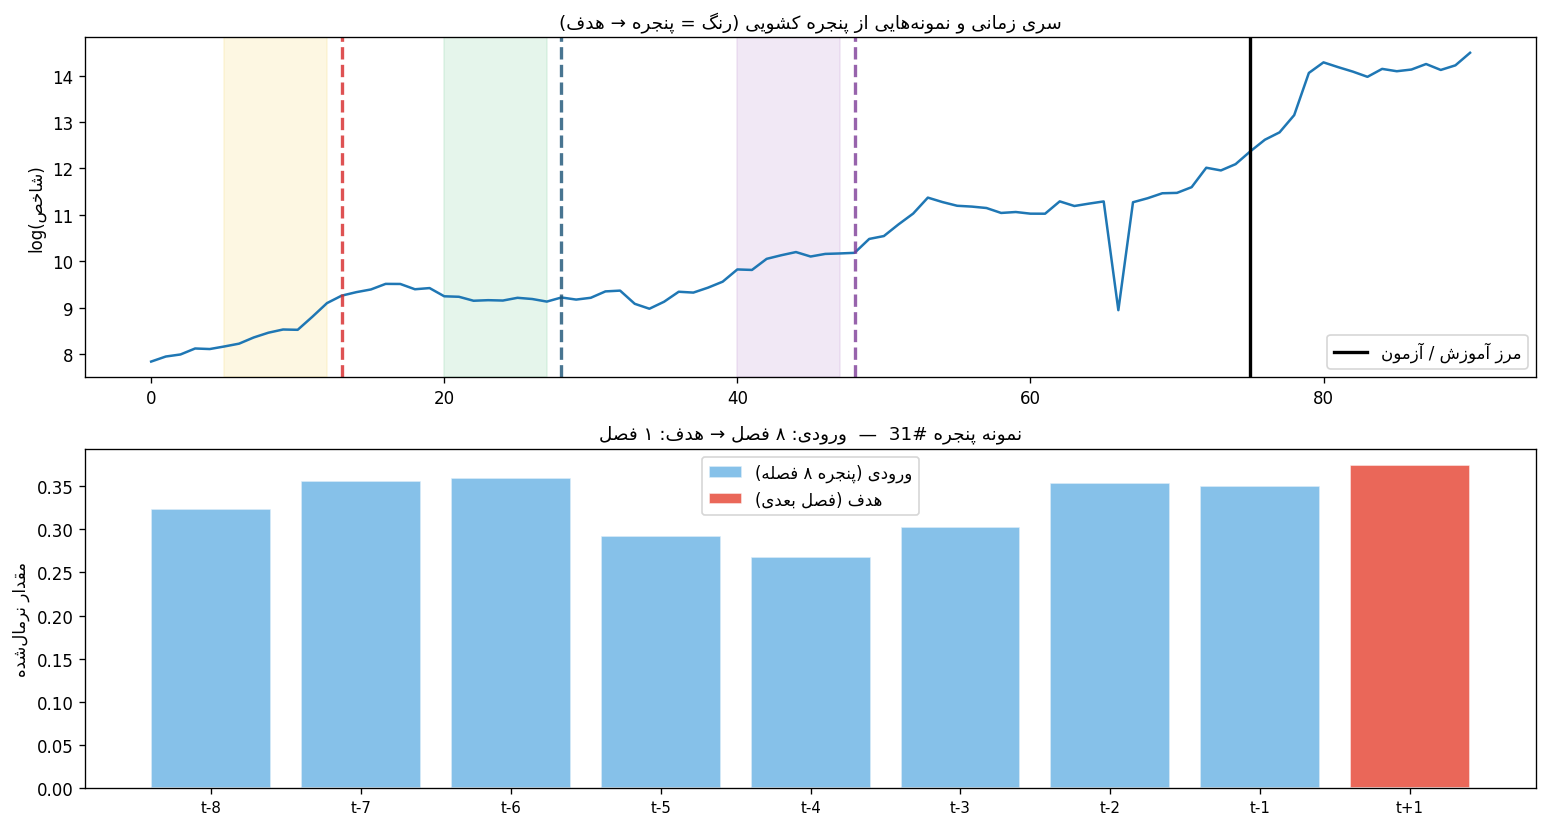

✓ نمودار ۱ ذخیره شد


In [25]:
# نمودار ۱ — نمایش بصری پنجره کشویی
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# بالا: سری کامل
ts = pd.concat([train["log_stock_price"], test["log_stock_price"]])
axes[0].plot(range(len(ts)), ts.values, color="#1f77b4", linewidth=1.5, zorder=2)
# رنگ‌آمیزی ۳ نمونه پنجره
for sample_i, col_win, col_tar in [(5,"#f9e79f","#d62728"),
                                    (20,"#a9dfbf","#1a5276"),
                                    (40,"#d2b4de","#7d3c98")]:
    axes[0].axvspan(sample_i, sample_i+WINDOW-1, alpha=0.3, color=col_win)
    axes[0].axvline(sample_i+WINDOW, color=col_tar, linewidth=2,
                    linestyle="--", alpha=0.8)
axes[0].axvline(N_TRAIN, color="black", linewidth=2, linestyle="-",
                label=fp("مرز آموزش / آزمون"))
axes[0].set_title(fp("سری زمانی و نمونه‌هایی از پنجره کشویی (رنگ = پنجره → هدف)"), fontsize=11)
axes[0].set_ylabel(fp("log(شاخص)"))
axes[0].legend()

# پایین: یک پنجره نمونه به تفصیل
sample_idx = 30
win_vals  = y_train_sc[sample_idx : sample_idx+WINDOW]
tgt_val   = y_train_sc[sample_idx+WINDOW]
axes[1].bar(range(WINDOW), win_vals, color="#5dade2", alpha=0.75, edgecolor="white",
            label=fp("ورودی (پنجره ۸ فصله)"))
axes[1].bar(WINDOW, tgt_val, color="#e74c3c", alpha=0.85, edgecolor="white",
            label=fp("هدف (فصل بعدی)"))
axes[1].set_xticks(range(WINDOW+1))
axes[1].set_xticklabels([f"t-{WINDOW-i}" for i in range(WINDOW)] + ["t+1"],
                         fontsize=9)
axes[1].set_title(fp(f"نمونه پنجره #{sample_idx+1}  —  ورودی: ۸ فصل → هدف: ۱ فصل"), fontsize=11)
axes[1].set_ylabel(fp("مقدار نرمال‌شده"))
axes[1].legend()
plt.tight_layout()
plt.savefig("../results/figures/03_sliding_window.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۱ ذخیره شد")

## ۴. تعریف معماری GRU

In [26]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, dropout=0.25):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        # ── لایه GRU (dropout بین لایه‌ها اعمال می‌شود اگر num_layers>1)
        self.gru = nn.GRU(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        # ── لایه‌های خروجی
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size // 2, 1)
        )
    
    def forward(self, x):
        # x: (batch, window, input_size)
        gru_out, _ = self.gru(x)           # (batch, window, hidden)
        last        = gru_out[:, -1, :]    # (batch, hidden)  ← آخرین timestep
        last        = self.dropout(last)
        return self.fc(last).squeeze(-1)   # (batch,)

# ── نمایش معماری
model_preview = GRUModel(hidden_size=32)
total_params = sum(p.numel() for p in model_preview.parameters())
print("معماری مدل:")
print(model_preview)
print(f"\n✓ تعداد کل پارامتر: {total_params:,}")
print(f"  نسبت نمونه/پارامتر: {len(X_seq_tr)/total_params:.2f}  (ایده‌آل > 5)")

معماری مدل:
GRUModel(
  (gru): GRU(1, 32, num_layers=2, batch_first=True, dropout=0.25)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)

✓ تعداد کل پارامتر: 10,241
  نسبت نمونه/پارامتر: 0.01  (ایده‌آل > 5)


## ۵. نمودار بصری معماری GRU

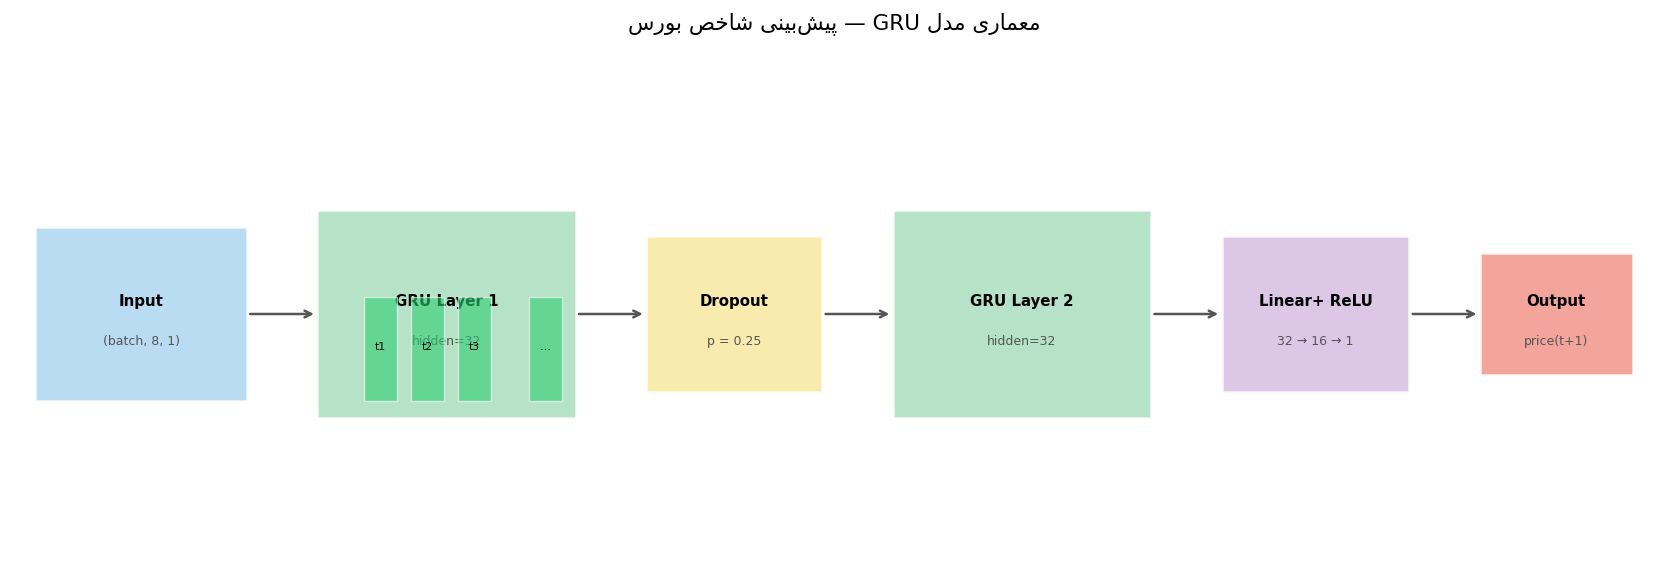

✓ نمودار ۲ ذخیره شد


In [27]:
# نمودار ۲ — رسم بصری معماری
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")
ax.set_xlim(0, 14); ax.set_ylim(0, 6)

def box(x, y, w, h, txt, col, sub=None):
    rect = plt.Rectangle((x, y), w, h, fc=col, ec="white", lw=1.5, zorder=3, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2 + (0.15 if sub else 0), txt, ha="center", va="center",
            fontsize=9, fontweight="bold", zorder=4)
    if sub:
        ax.text(x+w/2, y+h/2 - 0.3, sub, ha="center", va="center", fontsize=7.5,
                color="#555", zorder=4)

def arrow(x1, x2, y_):
    ax.annotate("", xy=(x2, y_), xytext=(x1, y_),
                 arrowprops=dict(arrowstyle="->", color="#555", lw=1.5))

# ورودی
box(0.2, 2, 1.8, 2, "Input", "#aed6f1", f"(batch, {WINDOW}, 1)")
arrow(2.0, 2.6, 3)
# GRU Layer 1
box(2.6, 1.8, 2.2, 2.4, "GRU Layer 1", "#a9dfbf", "hidden=32")
# نمایش cell های GRU داخل
for ti, tx in enumerate([3.0, 3.4, 3.8, 4.4]):
    sub_rect = plt.Rectangle((tx, 2.0), 0.28, 1.2, fc="#2ecc71", ec="white",
                               lw=0.8, zorder=5, alpha=0.6)
    ax.add_patch(sub_rect)
    ax.text(tx+0.14, 2.6, f"t{ti+1}" if ti<3 else "…", ha="center",
            fontsize=6.5, zorder=6)
arrow(4.8, 5.4, 3)
# Dropout
box(5.4, 2.1, 1.5, 1.8, "Dropout", "#f9e79f", "p = 0.25")
arrow(6.9, 7.5, 3)
# GRU Layer 2
box(7.5, 1.8, 2.2, 2.4, "GRU Layer 2", "#a9dfbf", "hidden=32")
arrow(9.7, 10.3, 3)
# Linear block
box(10.3, 2.1, 1.6, 1.8, "Linear+ ReLU", "#d7bde2", "32 → 16 → 1")
arrow(11.9, 12.5, 3)
# Output
box(12.5, 2.3, 1.3, 1.4, "Output", "#f1948a", "price(t+1)")

ax.set_title(fp("معماری مدل GRU — پیش‌بینی شاخص بورس"), fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("../results/figures/03_architecture.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۲ ذخیره شد")

## ۶. ساخت Dataset و تقسیم Train/Validation

In [28]:
class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X).to(DEVICE)
        self.y = torch.FloatTensor(y).to(DEVICE)
    def __len__(self):    return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

# ── تقسیم زمانی: آخرین ۱۵ دنباله برای validation
N_VAL   = 15
X_tr_nn = X_seq_tr[:-N_VAL]
y_tr_nn = y_seq_tr[:-N_VAL]
X_vl_nn = X_seq_tr[-N_VAL:]
y_vl_nn = y_seq_tr[-N_VAL:]

tr_loader = DataLoader(TSDataset(X_tr_nn, y_tr_nn), batch_size=16, shuffle=False)
vl_loader = DataLoader(TSDataset(X_vl_nn, y_vl_nn), batch_size=16, shuffle=False)

print(f"✓ train sequences : {len(X_tr_nn)}")
print(f"✓ val   sequences : {len(X_vl_nn)}")

✓ train sequences : 52
✓ val   sequences : 15


## ۷. جستجوی هایپرپارامتر — hidden_size

برای انتخاب اندازه بهینه لایه GRU، ۴ مقدار مختلف را با ۸۰ epoch آزمایش می‌کنیم.

In [29]:
HIDDEN_CANDIDATES = [8, 16, 32, 64]
QUICK_EPOCHS      = 80
hp_results        = {}

for hs in HIDDEN_CANDIDATES:
    m_hp   = GRUModel(hidden_size=hs).to(DEVICE)
    opt_hp = torch.optim.Adam(m_hp.parameters(), lr=0.01, weight_decay=1e-4)
    crit   = nn.MSELoss()
    best_val = np.inf
    for ep in range(QUICK_EPOCHS):
        m_hp.train()
        for Xb, yb in tr_loader:
            opt_hp.zero_grad()
            loss = crit(m_hp(Xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m_hp.parameters(), 1.0)
            opt_hp.step()
        m_hp.eval()
        with torch.no_grad():
            val_preds = m_hp(torch.FloatTensor(X_vl_nn).to(DEVICE)).cpu().numpy()
        vl = np.sqrt(mean_squared_error(y_vl_nn, val_preds))
        if vl < best_val: best_val = vl
    hp_results[hs] = best_val
    print(f"  hidden={hs:3d} → best val RMSE = {best_val:.5f}")

BEST_HIDDEN = min(hp_results, key=hp_results.get)
print(f"\n✓ بهترین hidden_size: {BEST_HIDDEN}")

  hidden=  8 → best val RMSE = 0.16414
  hidden= 16 → best val RMSE = 0.16242
  hidden= 32 → best val RMSE = 0.16289
  hidden= 64 → best val RMSE = 0.16278

✓ بهترین hidden_size: 16


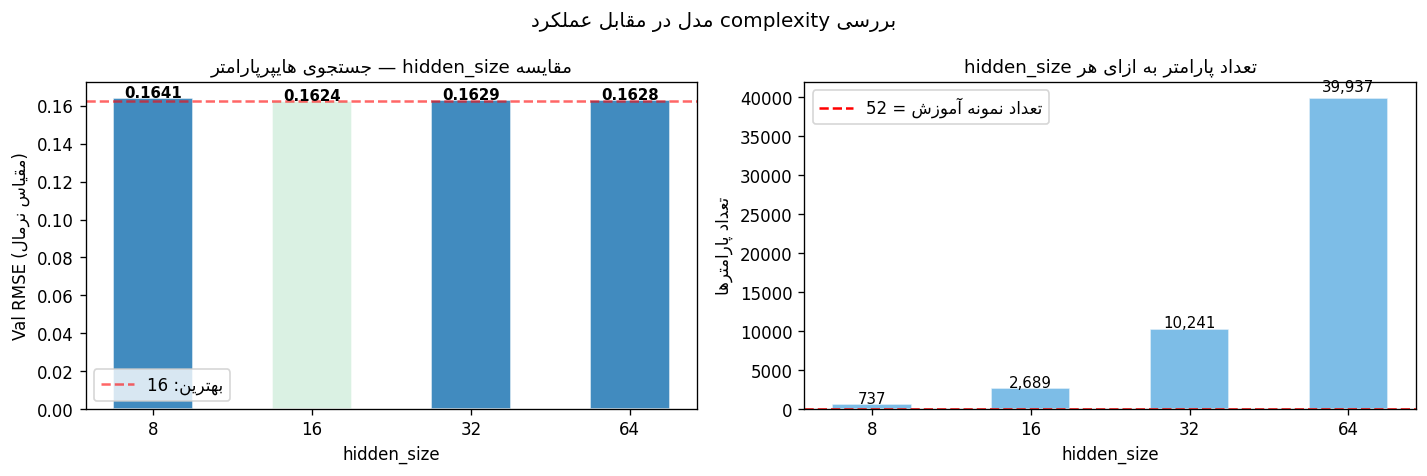

✓ نمودار ۳ ذخیره شد


In [30]:
# نمودار ۳ — مقایسه hidden_size
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sizes  = list(hp_results.keys())
losses = list(hp_results.values())
colors = ["#d4efdf" if s == BEST_HIDDEN else "#1f77b4" for s in sizes]
bars   = axes[0].bar([str(s) for s in sizes], losses,
                      color=colors, edgecolor="white", alpha=0.85, width=0.5)
for bar, val in zip(bars, losses):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
                 f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
axes[0].set_xlabel(fp("hidden_size"))
axes[0].set_ylabel(fp("Val RMSE (مقیاس نرمال)"))
axes[0].set_title(fp("مقایسه hidden_size — جستجوی هایپرپارامتر"), fontsize=11)
axes[0].axhline(min(losses), color="red", linestyle="--", alpha=0.6,
                label=fp(f"بهترین: {BEST_HIDDEN}"))
axes[0].legend()

# تعداد پارامترها
param_counts = [sum(p.numel() for p in GRUModel(hidden_size=h).parameters())
                for h in sizes]
axes[1].bar([str(s) for s in sizes], param_counts,
             color="#5dade2", alpha=0.8, edgecolor="white", width=0.5)
for bar, val in zip(axes[1].patches, param_counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                 f"{val:,}", ha="center", fontsize=9)
axes[1].set_xlabel(fp("hidden_size"))
axes[1].set_ylabel(fp("تعداد پارامترها"))
axes[1].set_title(fp("تعداد پارامتر به ازای هر hidden_size"), fontsize=11)
axes[1].axhline(len(X_tr_nn), color="red", linestyle="--",
                label=fp(f"تعداد نمونه آموزش = {len(X_tr_nn)}"))
axes[1].legend()

plt.suptitle(fp("بررسی complexity مدل در مقابل عملکرد"), fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/03_hyperparameter_search.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۳ ذخیره شد")

## ۸. آموزش مدل نهایی با EarlyStopping

**EarlyStopping:** اگر validation loss برای ۳۵ epoch بهبود نیابد، آموزش متوقف می‌شود.
**ReduceLR:** اگر val loss برای ۱۵ epoch بهبود نیابد، نرخ یادگیری نصف می‌شود.

In [31]:
MAX_EPOCHS = 400
PATIENCE   = 35
LR_PATIENCE= 15

model     = GRUModel(hidden_size=BEST_HIDDEN).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="min", factor=0.5, patience=LR_PATIENCE)
criterion = nn.MSELoss()

history = {"train_loss":[], "val_loss":[], "lr":[], "grad_norm":[]}
best_val  = np.inf
best_wts  = None
no_improve= 0

for epoch in range(1, MAX_EPOCHS+1):
    # ── Train
    model.train()
    ep_loss, total_gnorm = 0.0, 0.0
    for Xb, yb in tr_loader:
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ep_loss    += loss.item()
        total_gnorm+= gnorm
    train_loss = ep_loss / len(tr_loader)
    avg_gnorm  = total_gnorm / len(tr_loader)
    
    # ── Validate
    model.eval()
    with torch.no_grad():
        vl_pred = model(torch.FloatTensor(X_vl_nn).to(DEVICE)).cpu().numpy()
    val_loss = float(np.sqrt(mean_squared_error(y_vl_nn, vl_pred)))
    
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)
    history["grad_norm"].append(float(avg_gnorm))
    
    if val_loss < best_val:
        best_val  = val_loss
        best_wts  = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
    
    if epoch % 50 == 0 or epoch == 1:
        print(f"  Epoch {epoch:4d} | train={train_loss:.5f} | val={val_loss:.5f} | "
              f"lr={current_lr:.6f} | grad={float(avg_gnorm):.4f}")
    
    if no_improve >= PATIENCE:
        print(f"\n  ⏹ EarlyStopping در epoch {epoch} (best val={best_val:.5f})")
        break

# بارگذاری بهترین وزن‌ها
model.load_state_dict(best_wts)
best_epoch = int(np.argmin(history["val_loss"])) + 1
print(f"\n✓ بهترین val loss در epoch {best_epoch}: {best_val:.5f}")

  Epoch    1 | train=0.11929 | val=0.54492 | lr=0.010000 | grad=0.6104
  Epoch   50 | train=0.00629 | val=0.17340 | lr=0.005000 | grad=0.1103

  ⏹ EarlyStopping در epoch 88 (best val=0.16456)

✓ بهترین val loss در epoch 53: 0.16456


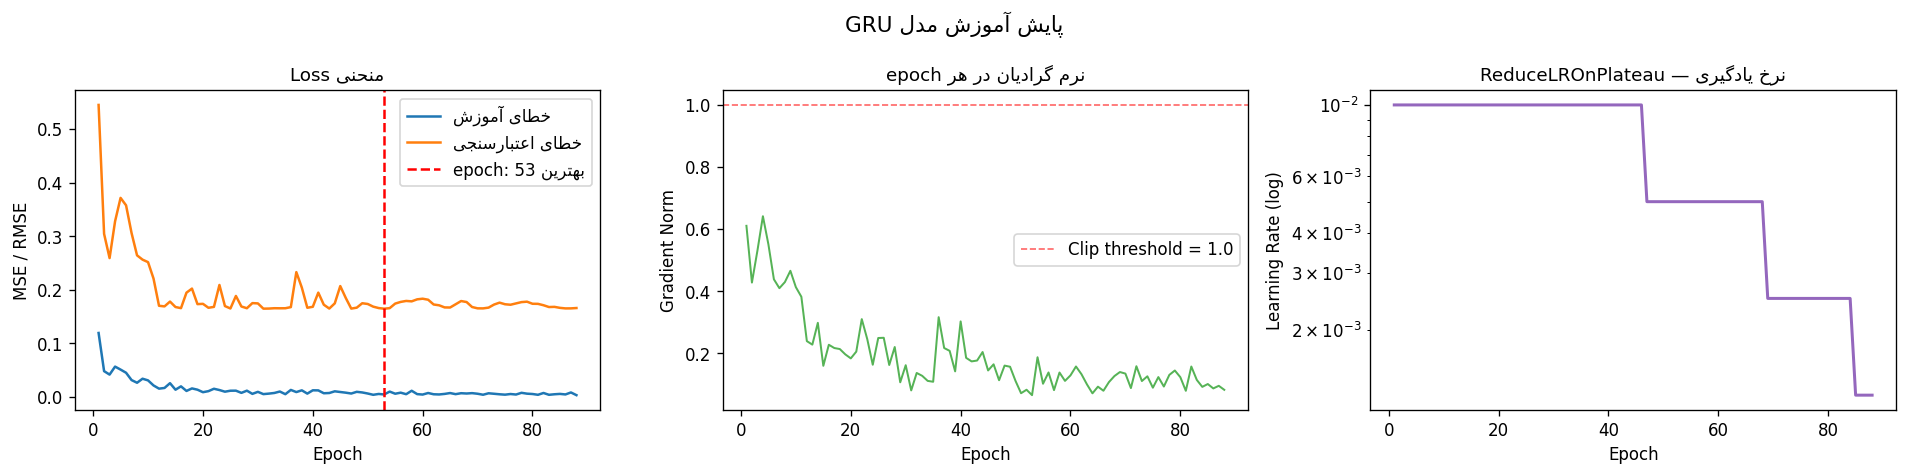

✓ نمودار ۴ ذخیره شد


In [32]:
# نمودار ۴ — منحنی‌های آموزش (loss + lr + gradient)
epochs_ran = range(1, len(history["train_loss"])+1)
fig, axes  = plt.subplots(1, 3, figsize=(16, 4))

# ── Loss
axes[0].plot(epochs_ran, history["train_loss"], color="#1f77b4", lw=1.5,
             label=fp("خطای آموزش"))
axes[0].plot(epochs_ran, history["val_loss"], color="#ff7f0e", lw=1.5,
             label=fp("خطای اعتبارسنجی"))
axes[0].axvline(best_epoch, color="red", lw=1.5, linestyle="--",
                label=fp(f"بهترین epoch: {best_epoch}"))
axes[0].set_title(fp("منحنی Loss"), fontsize=11)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE / RMSE")
axes[0].legend()

# ── Gradient norm
axes[1].plot(epochs_ran, history["grad_norm"], color="#2ca02c", lw=1.2, alpha=0.8)
axes[1].axhline(1.0, color="red", lw=1, linestyle="--", alpha=0.6,
                label="Clip threshold = 1.0")
axes[1].set_title(fp("نرم گرادیان در هر epoch"), fontsize=11)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel(fp("Gradient Norm"))
axes[1].legend()

# ── Learning rate schedule
axes[2].semilogy(epochs_ran, history["lr"], color="#9467bd", lw=1.8)
axes[2].set_title(fp("نرخ یادگیری — ReduceLROnPlateau"), fontsize=11)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel(fp("Learning Rate (log)"))

plt.suptitle(fp("پایش آموزش مدل GRU"), fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/03_training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۴ ذخیره شد")

## ۹. پیش‌بینی روی داده آزمون

In [33]:
model.eval()
with torch.no_grad():
    X_te_t    = torch.FloatTensor(X_seq_te).to(DEVICE)
    pred_sc   = model(X_te_t).cpu().numpy()

# ── برگرداندن به مقیاس اصلی
y_pred_log   = scaler.inverse_transform(pred_sc.reshape(-1,1)).flatten()
y_true_log   = test["log_stock_price"].values
y_pred_price = np.exp(y_pred_log)
y_true_price = test["stock_price"].values
test_dates   = test.index.to_timestamp()
x_t          = range(len(y_test_sc))

# ── جدول نتایج
result_df = pd.DataFrame({
    "دوره":     test.index.astype(str),
    "واقعی":    y_true_price.astype(int),
    "پیش‌بینی": y_pred_price.astype(int),
    "خطا (%)":  np.round((y_pred_price-y_true_price)/y_true_price*100, 2),
    "چرخه":     test["cycle"].values.astype(int)
})
print(result_df.to_string(index=False))

  دوره   واقعی  پیش‌بینی  خطا (%)  چرخه
2019Q1  234879    106307   -54.74     3
2019Q2  302104    112398   -62.79     1
2019Q3  353997    119362   -66.28     1
2019Q4  512901    126284   -75.38     1
2020Q1 1270627    134336   -89.43     1
2020Q2 1595160    146066   -90.84     1
2020Q3 1439124    156766   -89.11     1
2020Q4 1307707    164828   -87.40     1
2021Q1 1168665    170058   -85.45     1
2021Q2 1386451    172869   -87.53     1
2021Q3 1318360    175403   -86.70     1
2021Q4 1367250    177252   -87.04     1
2022Q1 1539632    178636   -88.40     1
2022Q2 1355241    179455   -86.76     1
2022Q3 1496201    179319   -88.02     1
2022Q4 1960457    179607   -90.84     1


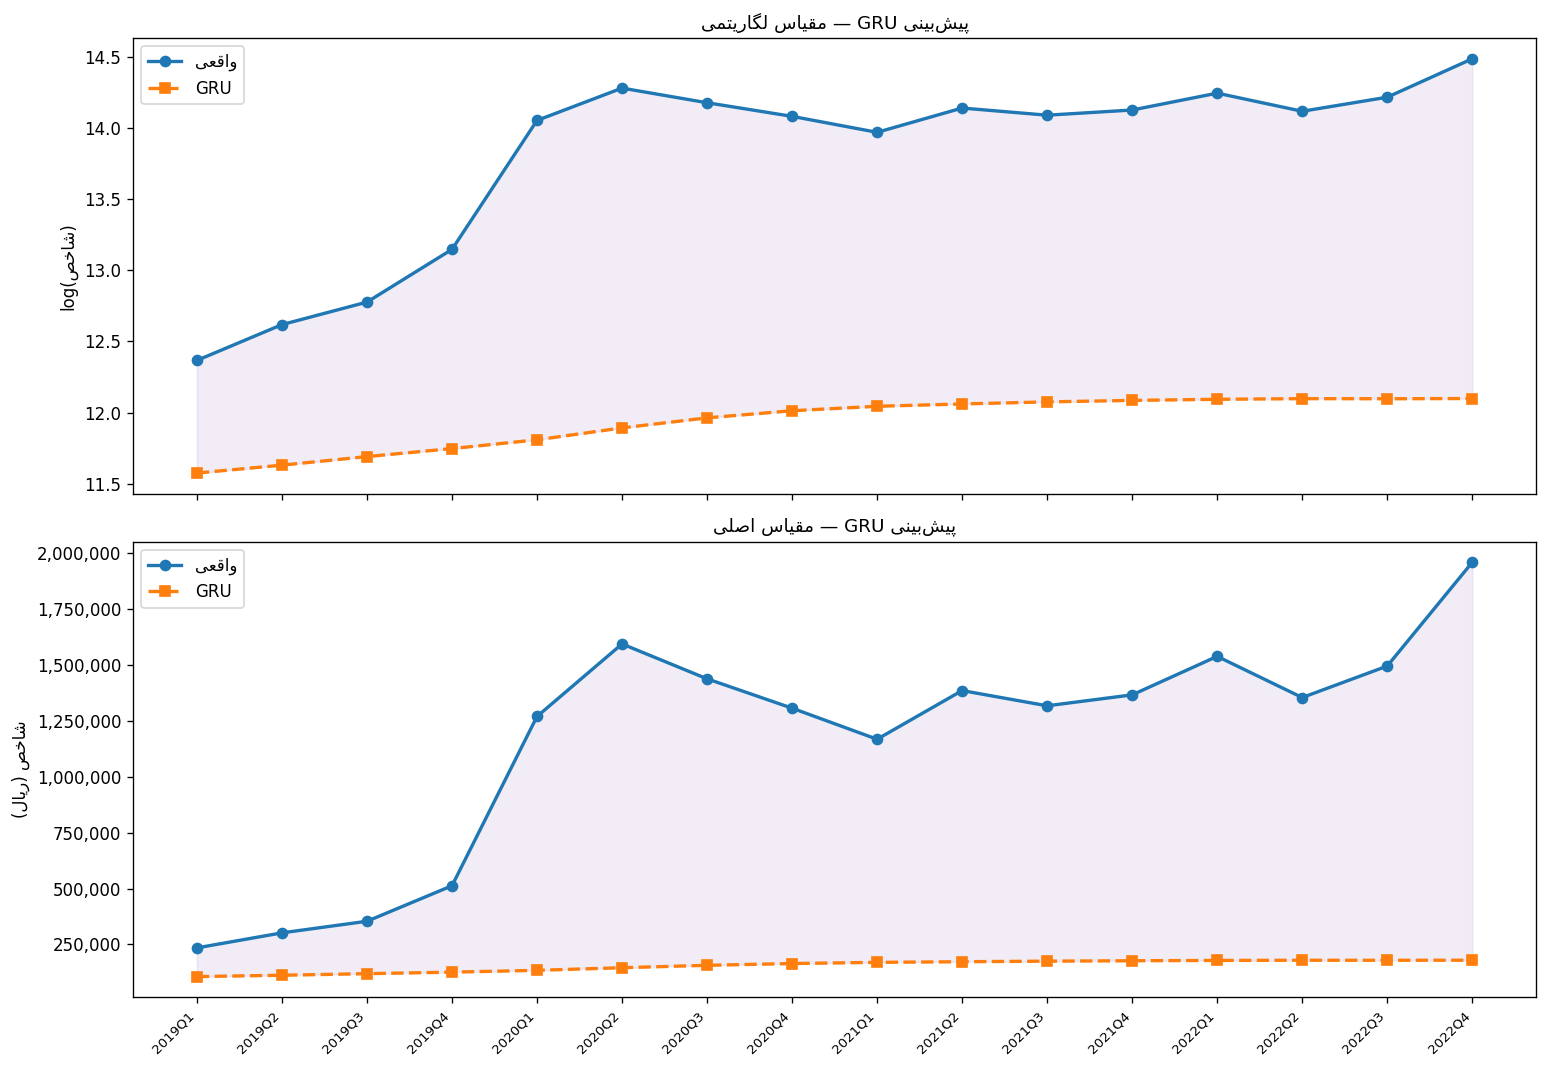

✓ نمودار ۵ ذخیره شد


In [34]:
# نمودار ۵ — Actual vs Predicted (log + price)
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# log scale
axes[0].plot(x_t, y_true_log, color="#1f77b4", marker="o", ms=6,
             lw=2, label=fp("واقعی"), zorder=4)
axes[0].plot(x_t, y_pred_log, color="#ff7f0e", marker="s", ms=6,
             lw=2, linestyle="--", label=fp("GRU"), zorder=4)
axes[0].fill_between(x_t, y_true_log, y_pred_log, alpha=0.12, color="#9467bd")
axes[0].set_ylabel(fp("log(شاخص)"))
axes[0].set_title(fp("پیش‌بینی GRU — مقیاس لگاریتمی"), fontsize=11)
axes[0].legend()

# price scale
axes[1].plot(x_t, y_true_price, color="#1f77b4", marker="o", ms=6,
             lw=2, label=fp("واقعی"), zorder=4)
axes[1].plot(x_t, y_pred_price, color="#ff7f0e", marker="s", ms=6,
             lw=2, linestyle="--", label=fp("GRU"), zorder=4)
axes[1].fill_between(x_t, y_true_price, y_pred_price, alpha=0.12, color="#9467bd")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
axes[1].set_ylabel(fp("شاخص (ریال)"))
axes[1].set_title(fp("پیش‌بینی GRU — مقیاس اصلی"), fontsize=11)
axes[1].set_xticks(x_t)
axes[1].set_xticklabels(test.index.astype(str), rotation=45, ha="right", fontsize=8)
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/figures/03_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۵ ذخیره شد")

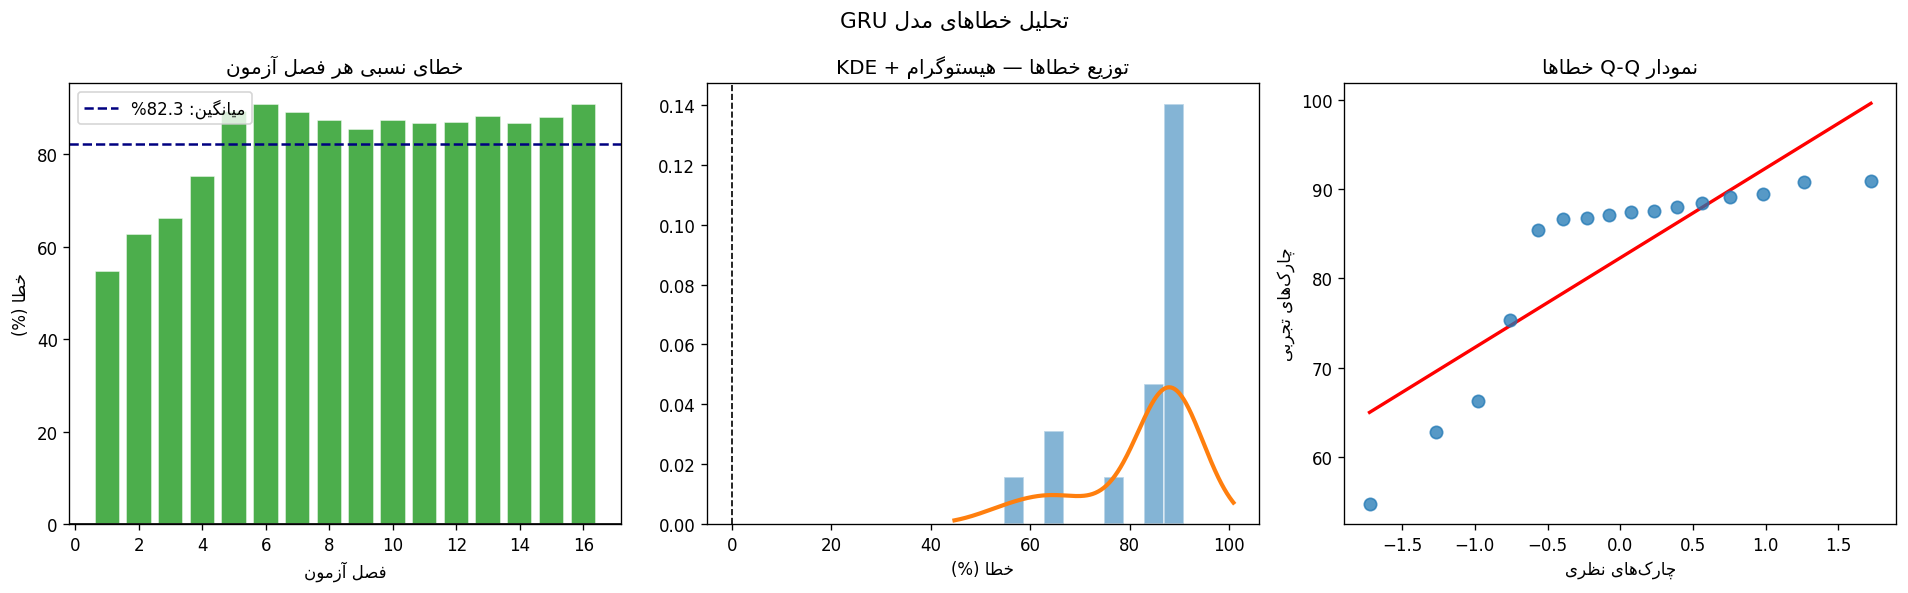

✓ نمودار ۶ ذخیره شد


In [35]:
# نمودار ۶ — تحلیل خطاها (bar + hist/KDE + QQ)
from scipy.stats import gaussian_kde, probplot
res_pct = (y_true_price - y_pred_price) / y_true_price * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# bar
bar_c = ["#2ca02c" if r > 0 else "#d62728" for r in res_pct]
axes[0].bar(range(1,17), res_pct, color=bar_c, alpha=0.85, edgecolor="white")
axes[0].axhline(0, color="black", lw=1)
axes[0].axhline(np.mean(res_pct), color="navy", lw=1.5, linestyle="--",
                label=fp(f"میانگین: {np.mean(res_pct):.1f}%"))
axes[0].set_title(fp("خطای نسبی هر فصل آزمون")); axes[0].legend()
axes[0].set_xlabel(fp("فصل آزمون")); axes[0].set_ylabel(fp("خطا (%)"))

# hist + KDE
axes[1].hist(res_pct, bins=9, color="#1f77b4", alpha=0.55, edgecolor="white", density=True)
x_kde = np.linspace(res_pct.min()-10, res_pct.max()+10, 300)
axes[1].plot(x_kde, gaussian_kde(res_pct)(x_kde), color="#ff7f0e", lw=2.5)
axes[1].axvline(0, color="black", lw=1, linestyle="--")
axes[1].set_title(fp("توزیع خطاها — هیستوگرام + KDE"))
axes[1].set_xlabel(fp("خطا (%)"))

# QQ
(osm, osr), (slope, intercept, _) = probplot(res_pct, dist="norm")
axes[2].scatter(osm, osr, color="#1f77b4", alpha=0.75, s=55, zorder=3)
xl = np.array([min(osm), max(osm)])
axes[2].plot(xl, slope*xl+intercept, color="red", lw=2)
axes[2].set_title(fp("نمودار Q-Q خطاها"))
axes[2].set_xlabel(fp("چارک‌های نظری")); axes[2].set_ylabel(fp("چارک‌های تجربی"))

plt.suptitle(fp("تحلیل خطاهای مدل GRU"), fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/03_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۶ ذخیره شد")

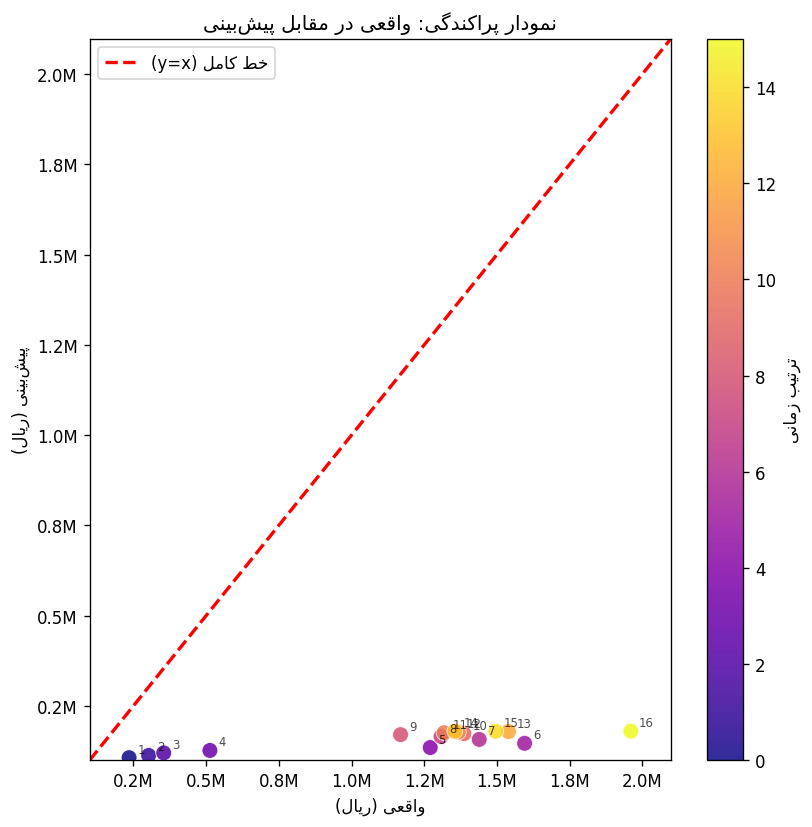

✓ نمودار ۷ ذخیره شد


In [36]:
# نمودار ۷ — Scatter: واقعی vs پیش‌بینی
fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(y_true_price, y_pred_price,
                c=range(16), cmap="plasma", s=90, alpha=0.85,
                edgecolors="white", lw=0.5, zorder=3)
lim_lo = min(y_true_price.min(), y_pred_price.min()) * 0.93
lim_hi = max(y_true_price.max(), y_pred_price.max()) * 1.07
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "r--", lw=2,
        label=fp("خط کامل (y=x)"))
for i, (xt, xp) in enumerate(zip(y_true_price, y_pred_price)):
    ax.annotate(str(i+1), (xt, xp), textcoords="offset points",
                xytext=(5,3), fontsize=7, alpha=0.7)
ax.set_xlim(lim_lo, lim_hi); ax.set_ylim(lim_lo, lim_hi)
ax.set_xlabel(fp("واقعی (ریال)")); ax.set_ylabel(fp("پیش‌بینی (ریال)"))
ax.set_title(fp("نمودار پراکندگی: واقعی در مقابل پیش‌بینی"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
ax.legend(); plt.colorbar(sc, ax=ax, label=fp("ترتیب زمانی"))
plt.tight_layout()
plt.savefig("../results/figures/03_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۷ ذخیره شد")

## ۱۰. عملکرد به تفکیک رژیم اقتصادی

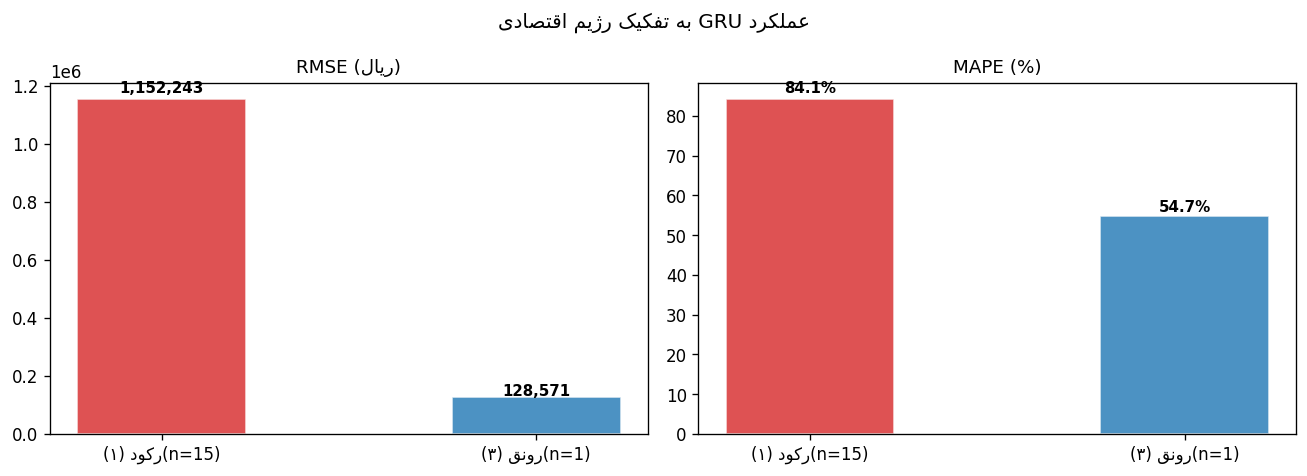

✓ نمودار ۸ ذخیره شد


In [37]:
# نمودار ۸ — عملکرد به تفکیک چرخه
cycle_vals   = test["cycle"].values
cycle_colors = {1:"#d62728", 2:"#2ca02c", 3:"#1f77b4"}
cyc_m = {}
for c in sorted(set(cycle_vals.astype(int))):
    mask = cycle_vals == c
    if not mask.any(): continue
    yt, yp = y_true_price[mask], y_pred_price[mask]
    cyc_m[c] = {"RMSE": np.sqrt(mean_squared_error(yt,yp)),
                "MAPE": np.mean(np.abs((yt-yp)/yt))*100, "n": mask.sum()}

cyc_names = {1: fp("رکود (۱)"), 2: fp("عادی (۲)"), 3: fp("رونق (۳)")}
keys = sorted(cyc_m.keys())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax_i, metric in enumerate(["RMSE","MAPE"]):
    vals   = [cyc_m[k][metric] for k in keys]
    labels = [f"{cyc_names.get(k,k)}(n={cyc_m[k]['n']})" for k in keys]
    colors = [cycle_colors.get(k,"gray") for k in keys]
    bars   = axes[ax_i].bar(labels, vals, color=colors, alpha=0.8,
                             edgecolor="white", width=0.45)
    for bar, v in zip(bars, vals):
        fmt = f"{v:,.0f}" if metric=="RMSE" else f"{v:.1f}%"
        axes[ax_i].text(bar.get_x()+bar.get_width()/2,
                         bar.get_height()*1.02, fmt,
                         ha="center", fontsize=9, fontweight="bold")
    unit = fp("ریال") if metric=="RMSE" else "%"
    axes[ax_i].set_title(f"{metric} ({unit})", fontsize=11)
plt.suptitle(fp("عملکرد GRU به تفکیک رژیم اقتصادی"), fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/03_performance_by_cycle.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۸ ذخیره شد")

## ۱۱. مقایسه سه مدل فاز ۲

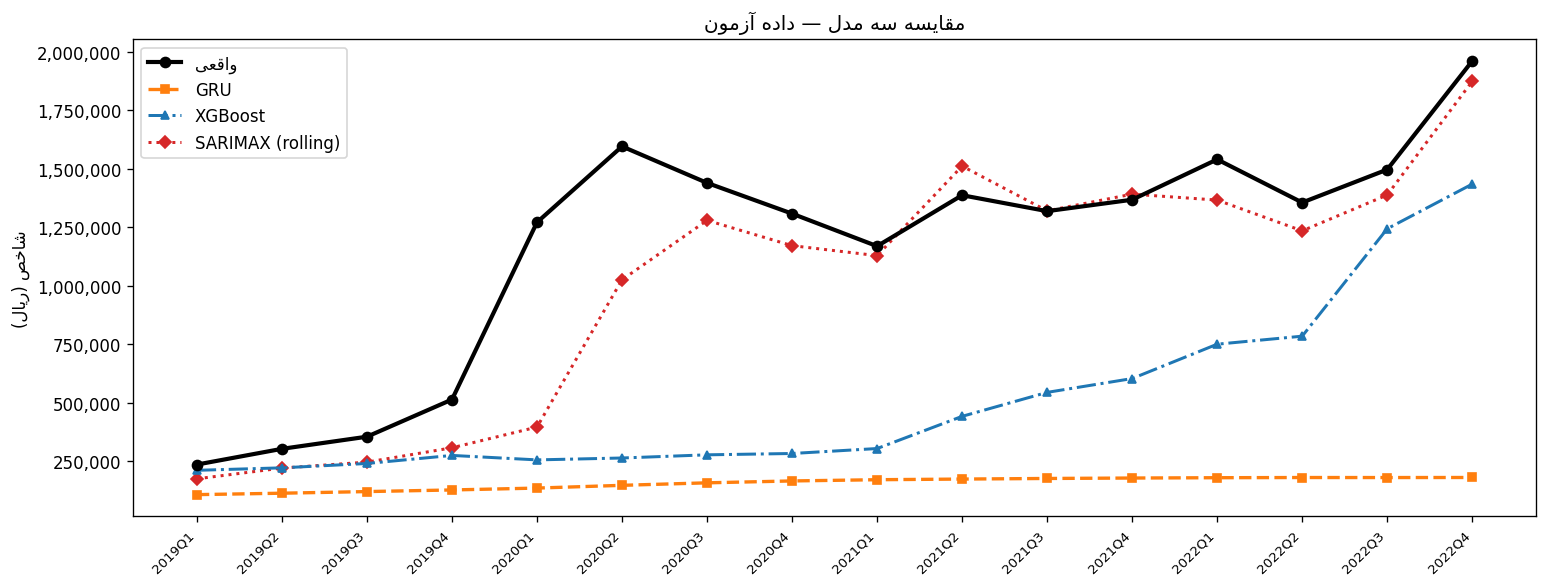

✓ نمودار ۹ ذخیره شد


In [38]:
# نمودار ۹ — مقایسه XGBoost + SARIMAX + GRU
xgb_path = "../results/metrics/01_xgboost_predictions.csv"
sar_path  = "../results/metrics/02_sarimax_predictions.csv"
has_xgb   = os.path.exists(xgb_path)
has_sar   = os.path.exists(sar_path)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x_t, y_true_price, color="black", marker="o", ms=6, lw=2.5,
        label=fp("واقعی"), zorder=6)
ax.plot(x_t, y_pred_price, color="#ff7f0e", marker="s", ms=5, lw=2,
        linestyle="--", label=fp("GRU"), zorder=5)
if has_xgb:
    xgb_df = pd.read_csv(xgb_path)
    ax.plot(x_t, xgb_df["پیش‌بینی"].values[:len(x_t)],
            color="#1f77b4", marker="^", ms=5, lw=1.8,
            linestyle="-.", label=fp("XGBoost"), zorder=4)
if has_sar:
    sar_df = pd.read_csv(sar_path)
    ax.plot(x_t, sar_df["predicted"].values[:len(x_t)],
            color="#d62728", marker="D", ms=5, lw=1.8,
            linestyle=":", label=fp("SARIMAX (rolling)"), zorder=3)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
ax.set_ylabel(fp("شاخص (ریال)")); ax.set_title(fp("مقایسه سه مدل — داده آزمون"), fontsize=12)
ax.set_xticks(x_t)
ax.set_xticklabels(test.index.astype(str), rotation=45, ha="right", fontsize=8)
ax.legend(); plt.tight_layout()
plt.savefig("../results/figures/03_all_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۹ ذخیره شد")

## ۱۲. معیارهای ارزیابی

In [39]:
RMSE = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
MAE  = mean_absolute_error(y_true_price, y_pred_price)
MAPE = np.mean(np.abs((y_true_price-y_pred_price)/y_true_price))*100
R2   = r2_score(y_true_price, y_pred_price)
metrics = {"model":"GRU","RMSE":RMSE,"MAE":MAE,"MAPE":MAPE,"R2":R2}

print("╔══════════════════════════════════════╗")
print(f"║  {'مدل: GRU':^36} ║")
print("╠══════════════════════════════════════╣")
print(f"║  {'RMSE':<10} {RMSE:>23,.2f}  ║")
print(f"║  {'MAE':<10} {MAE:>23,.2f}  ║")
print(f"║  {'MAPE':<10} {MAPE:>22.2f}%  ║")
print(f"║  {'R²':<10} {R2:>24.4f}  ║")
print("╚══════════════════════════════════════╝")

╔══════════════════════════════════════╗
║                مدل: GRU               ║
╠══════════════════════════════════════╣
║  RMSE                  1,116,117.87  ║
║  MAE                   1,008,112.56  ║
║  MAPE                        82.29%  ║
║  R²                          -3.9621  ║
╚══════════════════════════════════════╝


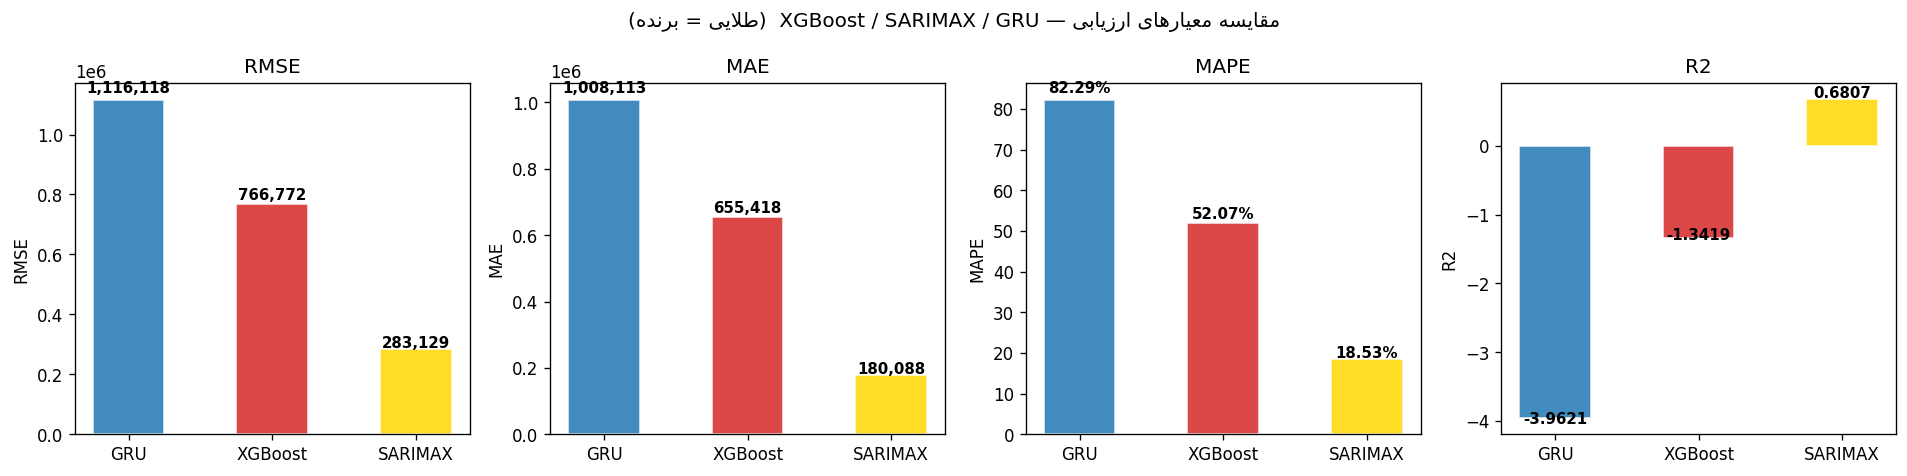

✓ نمودار ۱۰ ذخیره شد


In [40]:
# نمودار ۱۰ — مقایسه معیارهای هر ۳ مدل
all_metrics_path = "../results/metrics"
model_metrics    = {"GRU": {"RMSE":RMSE,"MAE":MAE,"MAPE":MAPE,"R2":R2}}
for fname, mname in [("01_xgboost_metrics.csv","XGBoost"),
                      ("02_sarimax_metrics.csv","SARIMAX")]:
    p = os.path.join(all_metrics_path, fname)
    if os.path.exists(p):
        row = pd.read_csv(p).iloc[0]
        model_metrics[mname] = {"RMSE":row["RMSE"],"MAE":row["MAE"],
                                 "MAPE":row["MAPE"],"R2":row["R2"]}

names = list(model_metrics.keys())
cols  = ["#1f77b4","#d62728","#ff7f0e"][:len(names)]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax_i, metric in enumerate(["RMSE","MAE","MAPE","R2"]):
    vals   = [model_metrics[n][metric] for n in names]
    winner = int(np.argmin(vals)) if metric != "R2" else int(np.argmax(vals))
    bar_c  = ["#ffd700" if i==winner else c for i, c in enumerate(cols[:len(names)])]
    bars   = axes[ax_i].bar(names, vals, color=bar_c, alpha=0.85, edgecolor="white", width=0.5)
    for bar, v in zip(bars, vals):
        fmt = f"{v:,.0f}" if metric in ["RMSE","MAE"] else               (f"{v:.2f}%" if metric=="MAPE" else f"{v:.4f}")
        axes[ax_i].text(bar.get_x()+bar.get_width()/2,
                         bar.get_height()*1.02, fmt,
                         ha="center", fontsize=9, fontweight="bold")
    axes[ax_i].set_title(metric, fontsize=12); axes[ax_i].set_ylabel(metric)
plt.suptitle(fp("مقایسه معیارهای ارزیابی — XGBoost / SARIMAX / GRU  (طلایی = برنده)"),
             fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/03_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۱۰ ذخیره شد")

## ۱۳. ذخیره مدل و نتایج

In [41]:
os.makedirs("../models",          exist_ok=True)
os.makedirs("../results/metrics", exist_ok=True)

torch.save(model.state_dict(), "../models/03_gru_weights.pt")
torch.save({"model_state": model.state_dict(),
             "scaler": scaler,
             "window": WINDOW,
             "hidden_size": BEST_HIDDEN,
             "best_epoch": best_epoch,
             "history": history},
           "../models/03_gru_checkpoint.pt")
pd.DataFrame([metrics]).to_csv("../results/metrics/03_gru_metrics.csv", index=False)
result_df.to_csv("../results/metrics/03_gru_predictions.csv", index=False)

print("✓ مدل ذخیره شد    : ../models/03_gru_checkpoint.pt")
print("✓ معیارها          : ../results/metrics/03_gru_metrics.csv")
figs = sorted([f for f in os.listdir("../results/figures") if f.startswith("03_")])
print(f"\n{'نمودار':5s}  فایل")
for f in figs: print(f"  📊  {f}")

✓ مدل ذخیره شد    : ../models/03_gru_checkpoint.pt
✓ معیارها          : ../results/metrics/03_gru_metrics.csv

نمودار  فایل
  📊  03_actual_vs_predicted.png
  📊  03_all_models_comparison.png
  📊  03_architecture.png
  📊  03_hyperparameter_search.png
  📊  03_metrics_comparison.png
  📊  03_performance_by_cycle.png
  📊  03_residuals.png
  📊  03_scatter.png
  📊  03_sliding_window.png
  📊  03_training_history.png


## ✅ خلاصه نتایج مدل GRU

| # | نمودار | نوع |
|---|--------|-----|
| ۱ | `03_sliding_window` | Bar + Line |
| ۲ | `03_architecture` | Diagram (matplotlib) |
| ۳ | `03_hyperparameter_search` | Bar (loss + params) |
| ۴ | `03_training_history` | Line (loss + grad + lr) |
| ۵ | `03_actual_vs_predicted` | Line (log + price) |
| ۶ | `03_residuals` | Bar + Hist/KDE + Q-Q |
| ۷ | `03_scatter` | Scatter + colorbar |
| ۸ | `03_performance_by_cycle` | Grouped Bar |
| ۹ | `03_all_models_comparison` | Multi-line |
| ۱۰ | `03_metrics_comparison` | Grouped Bar |

**مرحله بعدی:** `04_hybrid_pca_rf_gru.ipynb` — مدل showcase